# Setup

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from nds_toolbox.preprocessing.features import compute_wavelet

import seaborn as sns


In [201]:

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9


plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,


    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


# 3-state scenario

In [234]:
from nds_toolbox.preprocessing.features import choose_embedding_dim, trim_data
from sklearn.metrics import matthews_corrcoef
from nds_toolbox.preprocessing.features import compute_wavelet
from nds_toolbox.preprocessing.features import compute_tde
from nds_toolbox.models.dpgmm_numpyro import truncate
from nds_toolbox.preprocessing.features import trim_data
from nds_toolbox.models.dpgmm_numpyro import get_states
from nds_toolbox.utils.helper import match_states


fs = 250         # Sampling frequency in Hz.
n_seconds = 60   # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))


# Condition 1: frequency distances (3 states)
freqs_dist_range = [[10, 40], [15, 40], [20, 40], [25, 40], [30, 40],[35, 40]]  #30, 25, 20, 15, 10, 5Hz diff

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB




In [235]:
sim_cond_data = "3states"

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB


signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond_data}_data.npz')


#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']
bursts_sample = sim_data['bursts_sample']

print("shape of signal_sample", signal_sample.shape)

shape of signal_sample (5, 6, 11, 45000)


In [236]:

sim_cond = "3states_est_k"


performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)

df["burst_f"] = df["burst_f"].apply(tuple)

df.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.36989385, 'weights': [1.0], 'means...",0.7927581,4,2115331525,...,511.340475,0.638507,511.978982,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7927581
1,DP-GMM (Edge-removed),"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.36989385, 'weights': [1.0], 'means...",0.7927581,4,2115331525,...,511.340475,0.638507,511.978982,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7927581
2,DP-GMM (Imputed),"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.36989385, 'weights': [1.0], 'means...",0.7927581,4,2115331525,...,511.340475,0.638507,511.978982,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7927581
3,DP-GMM (Imputed & Edge-removed),"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.36989385, 'weights': [1.0], 'means...",0.7927581,4,2115331525,...,511.340475,0.638507,511.978982,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7927581
4,DP-GMM,"[-0.5952416563106664, 0.05149356404923021, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-8,"{'alpha': 0.3605842, 'weights': [1.0], 'means'...",0.7935847,4,2115331525,...,483.248551,0.103826,483.352377,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7935847


In [237]:
import numpy as np
import pandas as pd

from sklearn.metrics import matthews_corrcoef


RAW_METHOD = "DP-GMM"
EDGE_METHOD = "DP-GMM (Edge-removed)"


def recompute_edge_removed_from_raw(row, fs, edge_states_cv=0.1):
    """
    Recompute one DP-GMM edge-removed row using the raw DP-GMM row.
    """

    row = row.copy()

    freq = np.asarray(row["burst_f"])
    snr = row["snr"]

    print(f"Recomputing edge-removed: snr = {snr}; freqs = {freq}")

    true_states = np.asarray(row["true_states"])
    old_mcc = row["mcc"]

    est_params = row["est_params"]
    alpha = est_params["alpha"]

    # Use untruncated params if available.
    # If this is a genuinely raw DP-GMM row, weights/means/covs may already be the untruncated ones.
    weights = est_params.get("untrunc_weights", est_params.get("weights"))
    means = est_params.get("untrunc_means", est_params.get("means"))
    covs = est_params.get("untrunc_covs", est_params.get("covs"))

    signal = np.asarray(row["signal"])
    num_emb = int(row["num_emb"])

    # ------------------------------------------------------------
    # TDE
    # ------------------------------------------------------------
    tde_data = compute_tde(signal, num_emb)

    # ------------------------------------------------------------
    # Edge-state removal / truncation
    # ------------------------------------------------------------
    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(
        means,
        covs,
        weights,
        verbose=True,
        return_info=True,
        edge_states_cv=edge_states_cv,
    )

    num_active_states = int(len(trunc_weights))

    if num_active_states < 1:
        raise ValueError(
            f"No active states left after truncation. "
            f"snr={snr}, freq={freq}, old_mcc={old_mcc}"
        )

    # ------------------------------------------------------------
    # Decode states using truncated params
    # ------------------------------------------------------------
    est_states = get_states(
        tde_data,
        trunc_means,
        trunc_covs,
        trunc_weights,
    )

    est_states_onehot = np.eye(num_active_states, dtype=np.float32)[est_states]

    # ------------------------------------------------------------
    # Align true states to TDE support
    # ------------------------------------------------------------
    trimmed_states = trim_data(true_states, num_emb, verbose=False)

    true_states_onehot = np.eye(
        trimmed_states.max() + 1,
        dtype=np.float32,
    )[trimmed_states]

    # ------------------------------------------------------------
    # Match estimated states to true states
    # ------------------------------------------------------------
    order, reordered_est_states_onehot = match_states(
        true_states_onehot,
        est_states_onehot,
        verbose=False,
    )

    est_states = np.argmax(reordered_est_states_onehot, axis=1)

    # ------------------------------------------------------------
    # MCC
    # ------------------------------------------------------------
    new_mcc = matthews_corrcoef(trimmed_states, est_states)

    print("old raw mcc:", old_mcc)
    print("new edge-removed mcc:", new_mcc)

    # ------------------------------------------------------------
    # Overwrite row contents
    # ------------------------------------------------------------
    row["method"] = EDGE_METHOD
    row["mcc"] = float(new_mcc)
    row["est_states"] = np.asarray(est_states)
    row["num_states_active"] = num_active_states

    row["est_params"] = {
        "alpha": alpha,

        # edge-removed / truncated params
        "weights": trunc_weights,
        "means": trunc_means,
        "covs": trunc_covs,

        # preserve raw params
        "untrunc_weights": weights,
        "untrunc_means": means,
        "untrunc_covs": covs,

        "num_states_active": num_active_states,
        "trunc_info": trunc_info,
    }

    return row


# ------------------------------------------------------------
# Recompute Edge-removed rows from raw DP-GMM rows only
# ------------------------------------------------------------
raw_rows = df.loc[df["method"] == RAW_METHOD].copy()

edge_removed_rows = pd.DataFrame(
    [
        recompute_edge_removed_from_raw(row, fs=fs, edge_states_cv=0.1)
        for _, row in raw_rows.iterrows()
    ]
)

# Keep column order identical to original df
edge_removed_rows = edge_removed_rows.reindex(columns=df.columns)

# ------------------------------------------------------------
# Replace old DP-GMM (Edge-removed) rows
# ------------------------------------------------------------
df = df.loc[df["method"] != EDGE_METHOD].copy()

df = pd.concat(
    [df, edge_removed_rows],
    axis=0,
    ignore_index=True,
)

# Optional sanity check
print(df["method"].value_counts())

Recomputing edge-removed: snr = -10; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate]
  total components              : 11
  mass threshold                : 0.990

  Stage 1: mass truncation
    kept components             : 1
    kept original indices       : [0]
    retained weight mass        : 0.9999
    dropped weight mass         : 0.0001

  Stage 2: edge-state removal
    CV threshold                : 0.100
    removed components          : 0
    removed original indices    : []
    CVs in active set           : [0.0199]

  Final result
    final components kept       : 1
    final original indices      : [0]
    final retained weight mass  : 0.9999
    final dropped weight mass   : 0.0001
old raw mcc: 0.0
new edge-removed mcc: 0.0
Recomputing edge-removed: snr = -8; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate]
  total components              : 11
  mass threshold                : 0.990

  

In [238]:
df.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.36989385, 'weights': [1.0], 'means...",0.7927581,4,2115331525,...,511.340475,0.638507,511.978982,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7927581
1,DP-GMM (Imputed),"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.36989385, 'weights': [1.0], 'means...",0.7927581,4,2115331525,...,511.340475,0.638507,511.978982,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7927581
2,DP-GMM (Imputed & Edge-removed),"[-0.5975611300592039, 0.05174610422566351, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-10,"{'alpha': 0.36989385, 'weights': [1.0], 'means...",0.7927581,4,2115331525,...,511.340475,0.638507,511.978982,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7927581
3,DP-GMM,"[-0.5952416563106664, 0.05149356404923021, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-8,"{'alpha': 0.3605842, 'weights': [1.0], 'means'...",0.7935847,4,2115331525,...,483.248551,0.103826,483.352377,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7935847
4,DP-GMM (Imputed),"[-0.5952416563106664, 0.05149356404923021, 0.3...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-8,"{'alpha': 0.3605842, 'weights': [1.0], 'means'...",0.7935847,4,2115331525,...,483.248551,0.103826,483.352377,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7935847


In [240]:
#df_list = [pd.DataFrame(r) for r in res]

#df = pd.concat(df_list, axis = 0, ignore_index = True)

#df["burst_f"] = df["burst_f"].apply(tuple)


# extract parameters

snr_db = 6

snr_id = np.where(snr_range == snr_db)[0][0]
print(snr_id)
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 1


df = df.query("burst_f == @plot_f and snr == @snr_db")



# raw dpgmm
df_raw = df.query("method == 'DP-GMM'").iloc[sample_id]



#common across variants

signal = signal_sample[sample_id,freq_id, snr_id ]
bursts = bursts_sample[sample_id,freq_id, snr_id ]
true_states = states_sample[sample_id,freq_id, snr_id].astype(int)


num_emb = df_raw["num_emb"]
trimmed_signal = trim_data(signal, num_emb, verbose=False)
trimmed_bursts = trim_data(bursts, num_emb, verbose=False)
trimmed_states = trim_data(true_states, num_emb, verbose=False)
num_states_true = int(trimmed_states.max() +1)
true_states_onehot = np.eye(num_states_true)[trimmed_states]

trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))




#raw dpgmm results
mcc_raw = df_raw["mcc"]
num_states = df_raw["num_states"]

est_params_raw = df_raw["est_params"]
weights_raw = est_params_raw["weights"]
means_raw = est_params_raw["means"]
covs_raw = est_params_raw["covs"]
alpha_raw = est_params_raw["alpha"]

num_states_raw = len(weights_raw)
est_states_raw = df_raw["est_states"]
est_states_onehot_raw = np.eye(num_states_raw)[est_states_raw]




untrunc_weights_raw = est_params_raw["untrunc_weights"]
untrunc_means_raw = est_params_raw["untrunc_means"]
untrunc_covs_raw = est_params_raw["untrunc_covs"]


#dpgmm with edge removal

df_no_edge = df.query("method == 'DP-GMM (Edge-removed)'").iloc[sample_id]



num_states_no_edge = df_no_edge["num_states"]
est_states_no_edge = df_no_edge["est_states"]
est_states_onehot_no_edge = np.eye(num_states_no_edge)[est_states_no_edge]
mcc_no_edge = df_no_edge["mcc"]

#dpgmm with edge removal and imputation

df_no_edge_imputed = df.query("method == 'DP-GMM (Imputed & Edge-removed)'").iloc[sample_id]

num_states_no_edge_imputed = df_no_edge_imputed["num_states"]
est_states_no_edge_imputed = df_no_edge_imputed["est_states"]

est_states_onehot_no_edge_imputed = np.eye(num_states_no_edge_imputed)[est_states_no_edge_imputed]
mcc_no_edge_imputed = df_no_edge_imputed["mcc"]



print("upper bound:", num_states)
print("active states:", num_states_raw)
print("active states (no edges):", num_states_no_edge)
print("true states:", num_states_true)


print("mcc (raw)", mcc_raw)
print("mcc (without edge):", mcc_no_edge)
print("mcc (without edge & imputed):", mcc_no_edge_imputed)






8
upper bound: 11
active states: 10
active states (no edges): 11
true states: 3
mcc (raw) 0.7660915561074566
mcc (without edge): 0.9239752353372881
mcc (without edge & imputed): 0.9470308154129604


In [219]:
diags = [np.diag(cov) for cov in untrunc_covs_raw]

cv_vals = []
for d in diags:
    mu = np.mean(d)
    sd = np.std(d)
    cv = sd / (mu + 1e-12)
    cv_vals.append(cv)

cv_vals = np.array(cv_vals)
cv_vals.shape

(11,)

In [220]:
num_states_raw

10

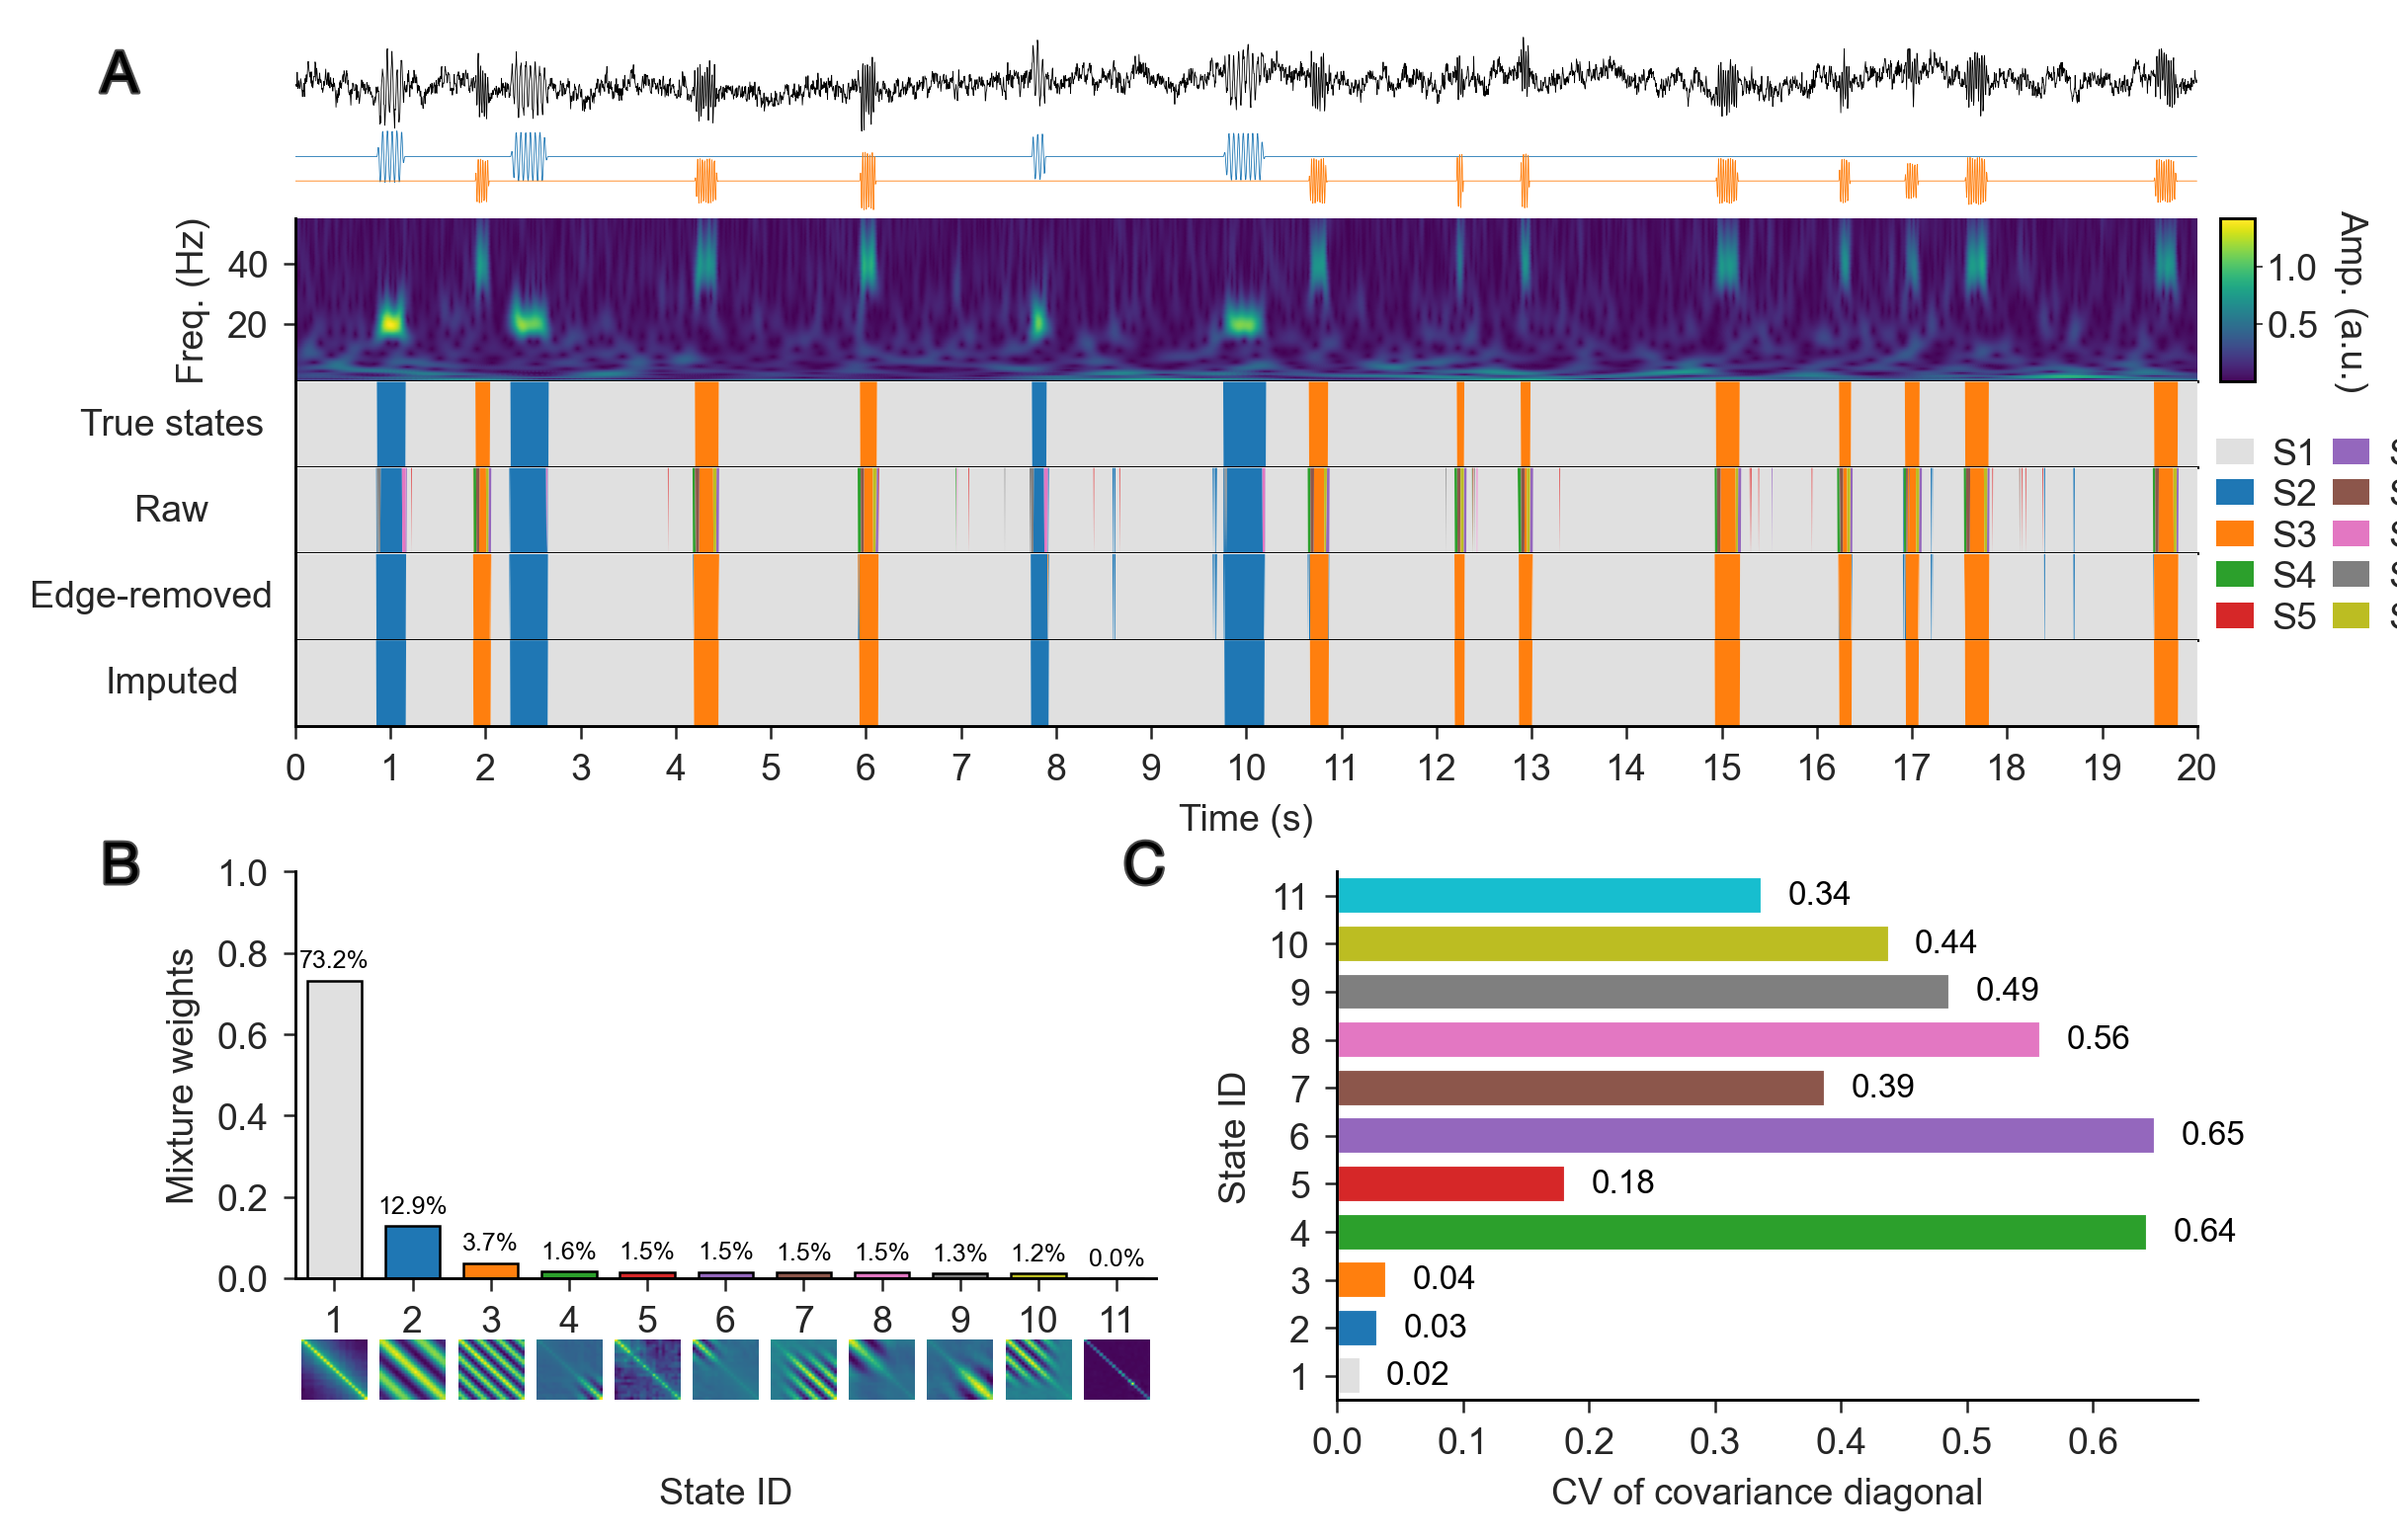

In [224]:

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


plot_t = 20
n_plot = int(round(plot_t * fs))


n_true_states = int(np.nanmax(trimmed_states)) + 1
n_raw_states = len(untrunc_weights_raw)

n_total_states = max(n_true_states, n_raw_states, num_states_raw)

cmap = plt.get_cmap("tab10")

colors = ["#E0E0E0"] + [cmap(i % 10) for i in range(n_total_states - 1)]
state_labels = [f"S{i}" for i in range(n_total_states)]

# One-hot true states
trimmed_states_onehot = np.eye(n_total_states)[trimmed_states.astype(int)]

# Wavelet
t, f, amp = compute_wavelet(
    trimmed_signal[:n_plot],
    fs,
    f_min=1,
    f_max=80,
    df=0.5,
    wavelet="cmor1.5-1.0",
)


mosaic = [
    ["a1", "a1", "."],
    ["a2", "a2", "cbar1"],
    ["a3", "a3", "leg"],
    ["a4", "a4", "leg"],
    ["a5", "a5", "leg"],
    ["a6", "a6", "leg"],
    ["gap", "gap", "."],
    ["b", "c", "."],
    ["d", "c", "."],
]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH+0.5, 5),
    constrained_layout=True,
    gridspec_kw={
        "height_ratios": [0.7, 0.6, 0.15, 0.15, 0.15, 0.15, 0.08, 1.5, 0.225],
        "width_ratios": [1, 1, 0.04],
    },
)

fig.set_constrained_layout_pads(
    w_pad=0.0,
    h_pad=0.0,
    wspace=0.01,
    hspace=0.001,
)

axes["gap"].axis("off")

#############
# simulated signal example
############

time_plot = trimmed_time_vec[:n_plot]

axes["a1"].plot(
    time_plot,
    1.5 * trimmed_signal[:n_plot],
    lw=0.2,
    color="k",
)

axes["a1"].grid(False)
axes["a1"].set_frame_on(False)

scale_burst = 1.5


for state_id in range(1, min(n_true_states, 4)):
    axes["a1"].plot(
        time_plot,
        -2 - state_id
        + scale_burst * (
                trimmed_bursts[:n_plot]
                * (trimmed_states[:n_plot] == state_id)
        ),
        lw=0.2,
        color=colors[state_id],
    )

axes["a1"].tick_params(
    axis="both",
    which="both",
    bottom=False,
    top=False,
    left=False,
    right=False,
    labelbottom=False,
    labelleft=False,
)

#########
# wavelet
#########

im = axes["a2"].imshow(
    amp,
    extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower",
    aspect="auto",
    cmap="viridis",
    vmin=np.nanmin(amp),
    vmax=np.nanmax(amp),
)

axes["a2"].tick_params(
    axis="x",
    which="both",
    bottom=False,
    top=False,
    labelbottom=False,
    labeltop=False,
)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))
axes["a2"].set_ylim(1, 55)
axes["a2"].set_ylabel("Freq. (Hz)")

cb = fig.colorbar(im, cax=axes["cbar1"])
cb.set_label("Amp. (a.u.)", rotation=270, labelpad=12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)

# Robust SVG/PDF colorbar rendering
if hasattr(cb, "solids") and cb.solids is not None:
    cb.solids.set_edgecolor("face")
    cb.solids.set_rasterized(True)

##########
# true and estimated states
#########
axes["a3"].stackplot(
    time_plot,
    trimmed_states_onehot[:n_plot].T,
    linewidth=0,
    colors=colors[:n_total_states],
)
axes["a3"].set_ylabel("True states", rotation=0, labelpad=30, va="center")

axes["a4"].stackplot(
    time_plot,
    est_states_onehot_raw[:n_plot].T,
    linewidth=0,
    colors=colors[:est_states_onehot_raw.shape[1]],
    labels=[f"S{i+1}" for i in range(est_states_onehot_raw.shape[1])],
)
axes["a4"].set_ylabel("Raw", rotation=0, labelpad=30, va="center")

axes["a5"].stackplot(
    time_plot,
    est_states_onehot_no_edge[:n_plot].T,
    linewidth=0,
    colors=colors[:est_states_onehot_no_edge.shape[1]],
)
axes["a5"].set_ylabel("Edge-removed", rotation=0, labelpad=35, va="center")

axes["a6"].stackplot(
    time_plot,
    est_states_onehot_no_edge_imputed[:n_plot].T,
    linewidth=0,
    colors=colors[:est_states_onehot_no_edge_imputed.shape[1]],
)
axes["a6"].set_ylabel(
    "Imputed",
    rotation=0,
    labelpad=30,
    va="center",
)


for key in ["a1", "a2", "a3", "a4", "a5", "a6"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4", "a5"]:
    axes[key].tick_params(
        axis="x",
        which="both",
        bottom=True,
        labelbottom=False,
        length=0,
    )
    axes[key].tick_params(
        axis="y",
        which="both",
        left=False,
        labelleft=False,
    )
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)
    axes[key].spines["bottom"].set_visible(True)

axes["a6"].set_xlabel("Time (s)")
axes["a6"].xaxis.set_major_locator(MultipleLocator(1.0))
axes["a6"].tick_params(axis="y", which="both", left=False, labelleft=False)
axes["a6"].set_yticks([])
axes["a6"].set_ylim(0, 1)
axes["a6"].set_xlim(0, plot_t)
axes["a6"].spines["bottom"].set_visible(True)

##########
# Legend
#########
handles, labels = axes["a4"].get_legend_handles_labels()

axes["leg"].axis("off")
state_legend = axes["leg"].legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(-1.5, 0.55),
    bbox_transform=axes["leg"].transAxes,
    frameon=False,
    handlelength=1,
    handletextpad=0.5,
    labelspacing=0.2,
    borderaxespad=0.0,
    ncol=2,
    columnspacing=0.4,
)

state_legend.set_in_layout(False)

##########
# mixture weights
# #########

x_states = np.arange(n_raw_states)

axes["b"].bar(
    x_states,
    untrunc_weights_raw,
    width=0.7,
    color=colors[:n_raw_states],
    edgecolor="k",
    linewidth=0.6,
    zorder=2,
)

for k, w in enumerate(untrunc_weights_raw):
    axes["b"].text(
        k,
        w + 0.02,
        f"{w * 100.0:.1f}%",
        ha="center",
        va="bottom",
        color="k",
        fontsize=MY_FONT_SIZE - 3,
    )

axes["b"].set_ylabel("Mixture weights")
axes["b"].set_xticks(x_states, labels=np.arange(1, n_raw_states+1))
axes["b"].set_ylim(0, 1)
axes["b"].set_xlim(-0.5, n_raw_states - 0.5)
axes["b"].tick_params(axis="y")

##########
# CV of covariance diagonals
#########
y_states = np.arange(n_raw_states)

axes["c"].barh(
    y_states,
    cv_vals,
    color=colors[:n_raw_states],
    alpha=1.0,
)

for i, cv in enumerate(cv_vals):
    axes["c"].text(
        cv + 0.02,
        i,
        f"{cv:.2f}",
        va="center",
        ha="left",
        fontsize=MY_FONT_SIZE - 1,
        color="black",
    )

axes["c"].set_yticks(y_states, labels=np.arange(1, n_raw_states+1))
axes["c"].set_xlabel("CV of covariance diagonal")
axes["c"].set_ylabel("State ID")

axes["c"].set_ylim(-0.5, n_raw_states - 0.5)


# ------------------------------------------------------------
# D: covariance thumbnails
# ------------------------------------------------------------

thumb_half_width = 0.42
thumb_y0 = -0.02
thumb_y1 = 0.8

axes["d"].set_xlim(-0.5, n_raw_states - 0.5)

for k in range(n_raw_states):
    im_dpgmm_cov = axes["d"].imshow(
        untrunc_covs_raw[k],
        extent=(
            k - thumb_half_width,
            k + thumb_half_width,
            thumb_y0,
            thumb_y1,
        ),
        cmap="viridis",
        origin="upper",
        aspect="auto",
    )
    im_dpgmm_cov.set_rasterized(True)

axes["d"].set_xlabel("State ID")
axes["d"].set_xlim(-0.5, n_raw_states - 0.5)
axes["d"].set_ylim(thumb_y0, thumb_y1)
axes["d"].set_xticks([])
axes["d"].set_yticks([])

for spine in axes["d"].spines.values():
    spine.set_visible(False)

fig.align_xlabels([axes["c"], axes["d"]])

fig.canvas.draw()
fig.set_constrained_layout(False)


state_keys = ["a3", "a4", "a5", "a6"]

pos = [axes[k].get_position() for k in state_keys]

x0 = min(p.x0 for p in pos)
x1 = max(p.x1 for p in pos)
y_top = max(p.y1 for p in pos)
y_bottom = min(p.y0 for p in pos)

n_rows = len(state_keys)
gap = 0.0
total_h = y_top - y_bottom
row_h = (total_h - gap * (n_rows - 1)) / n_rows

y1 = y_top

for key in state_keys:
    y0 = y1 - row_h
    axes[key].set_position([x0, y0, x1 - x0, row_h])
    y1 = y0 - gap


wavelet_cbar_left_shift = 0.014

pos_cbar1 = axes["cbar1"].get_position()
axes["cbar1"].set_position([
    pos_cbar1.x0 - wavelet_cbar_left_shift,
    pos_cbar1.y0,
    pos_cbar1.width,
    pos_cbar1.height,
])

###########
# panel label
###########

import matplotlib.patheffects as pe
from matplotlib.font_manager import FontProperties


# Finalize constrained_layout positions before reading axes positions
fig.canvas.draw()
fig.set_constrained_layout(False)




panel_font = FontProperties(
    family="Helvetica Neue",
    weight="heavy",
    size=14,
)

label_kw = dict(
    fontproperties=panel_font,
    color="k",
    ha="left",
    va="top",
    path_effects=[
        pe.withStroke(linewidth=1, foreground="0.30")
    ],
)

# Get axes positions in figure coordinates
pos_a = axes["a1"].get_position()
pos_b = axes["b"].get_position()
pos_c = axes["c"].get_position()

# A and B aligned to the same absolute figure x-position
x_left = 0.03

fig.text(
    x_left,
    min(pos_a.y1 + 0.035, 0.985),
    "A",
    transform=fig.transFigure,
    **label_kw,
)

fig.text(
    x_left,
    pos_b.y1 + 0.020,
    "B",
    transform=fig.transFigure,
    **label_kw,
)

fig.text(
    pos_c.x0 - 0.09,
    pos_c.y1 + 0.020,
    "C",
    transform=fig.transFigure,
    **label_kw,
)



# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

out_dir = Path("../figures/raw_figures")
out_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    out_dir / f"{sim_cond}_results_est_k.pdf",
    bbox_inches="tight",
    bbox_extra_artists=[state_legend],
)

fig.savefig(
    out_dir / f"{sim_cond}_results_est_k.svg",
    bbox_inches="tight",
    bbox_extra_artists=[state_legend],
)

plt.show()

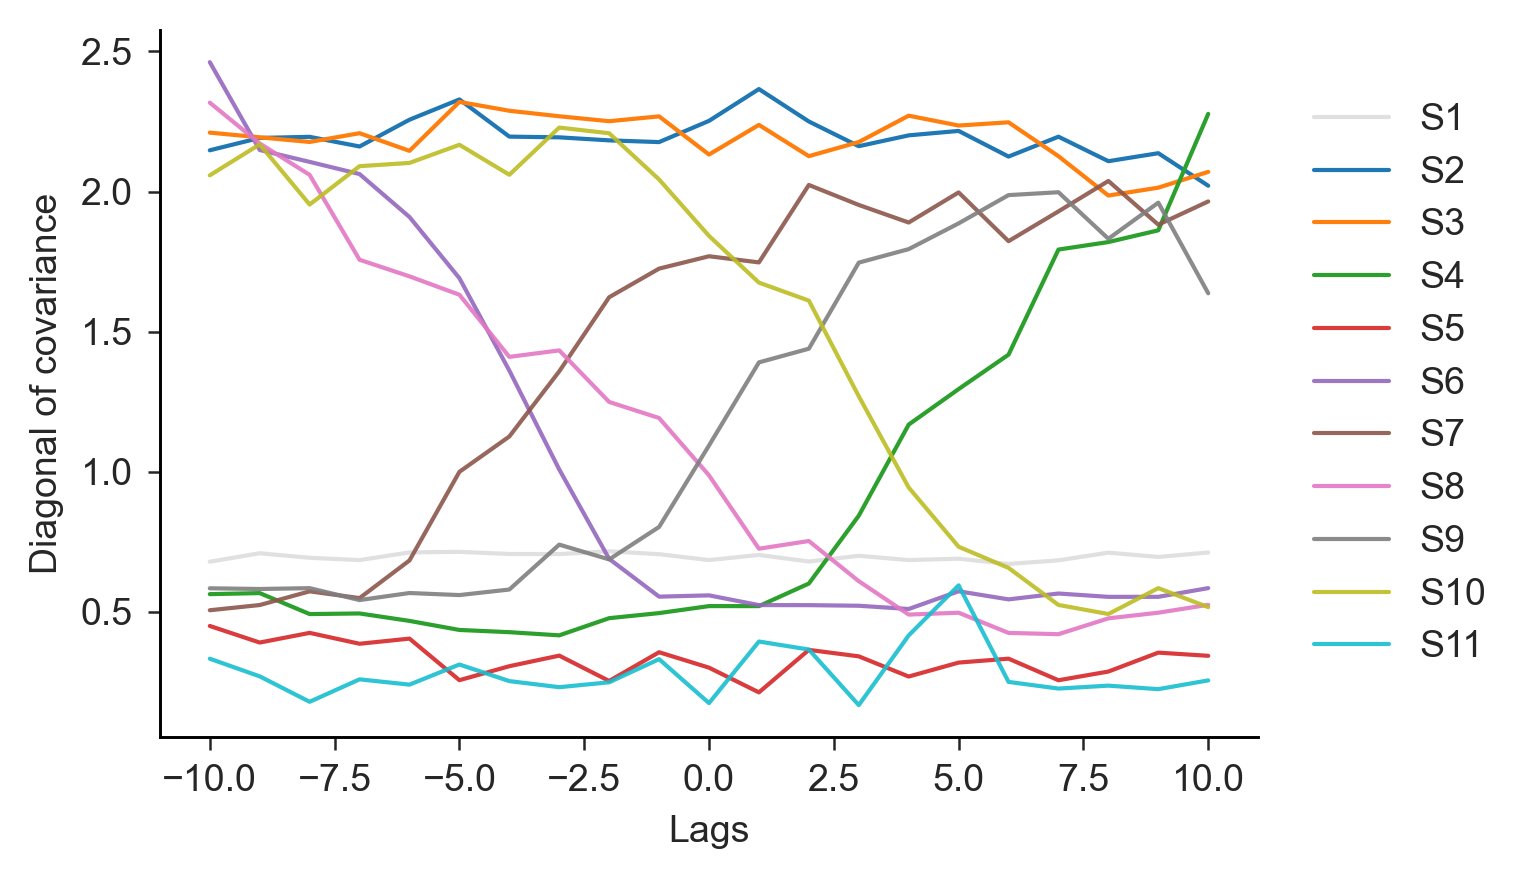

In [225]:
plt.figure(figsize=(FIG_WIDTH - 1, 3))


dim_vec = np.arange(-num_emb // 2 + 1, num_emb // 2 + 1).astype(int)


for i, cov in enumerate(untrunc_covs_raw):

    if i <= 3:
        plt.plot(dim_vec, np.diag(cov), label=f"S{i + 1}", color=colors[i], lw=1)

    else:
        plt.plot(dim_vec, np.diag(cov), label=f"S{i + 1}", color=colors[i], lw=1, alpha=0.9)

plt.xlabel("Lags")
plt.ylabel("Diagonal of covariance")

# legend outside (right)
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# leave room on the right for the legend
plt.tight_layout(rect=[0, 0, 0.80, 1])

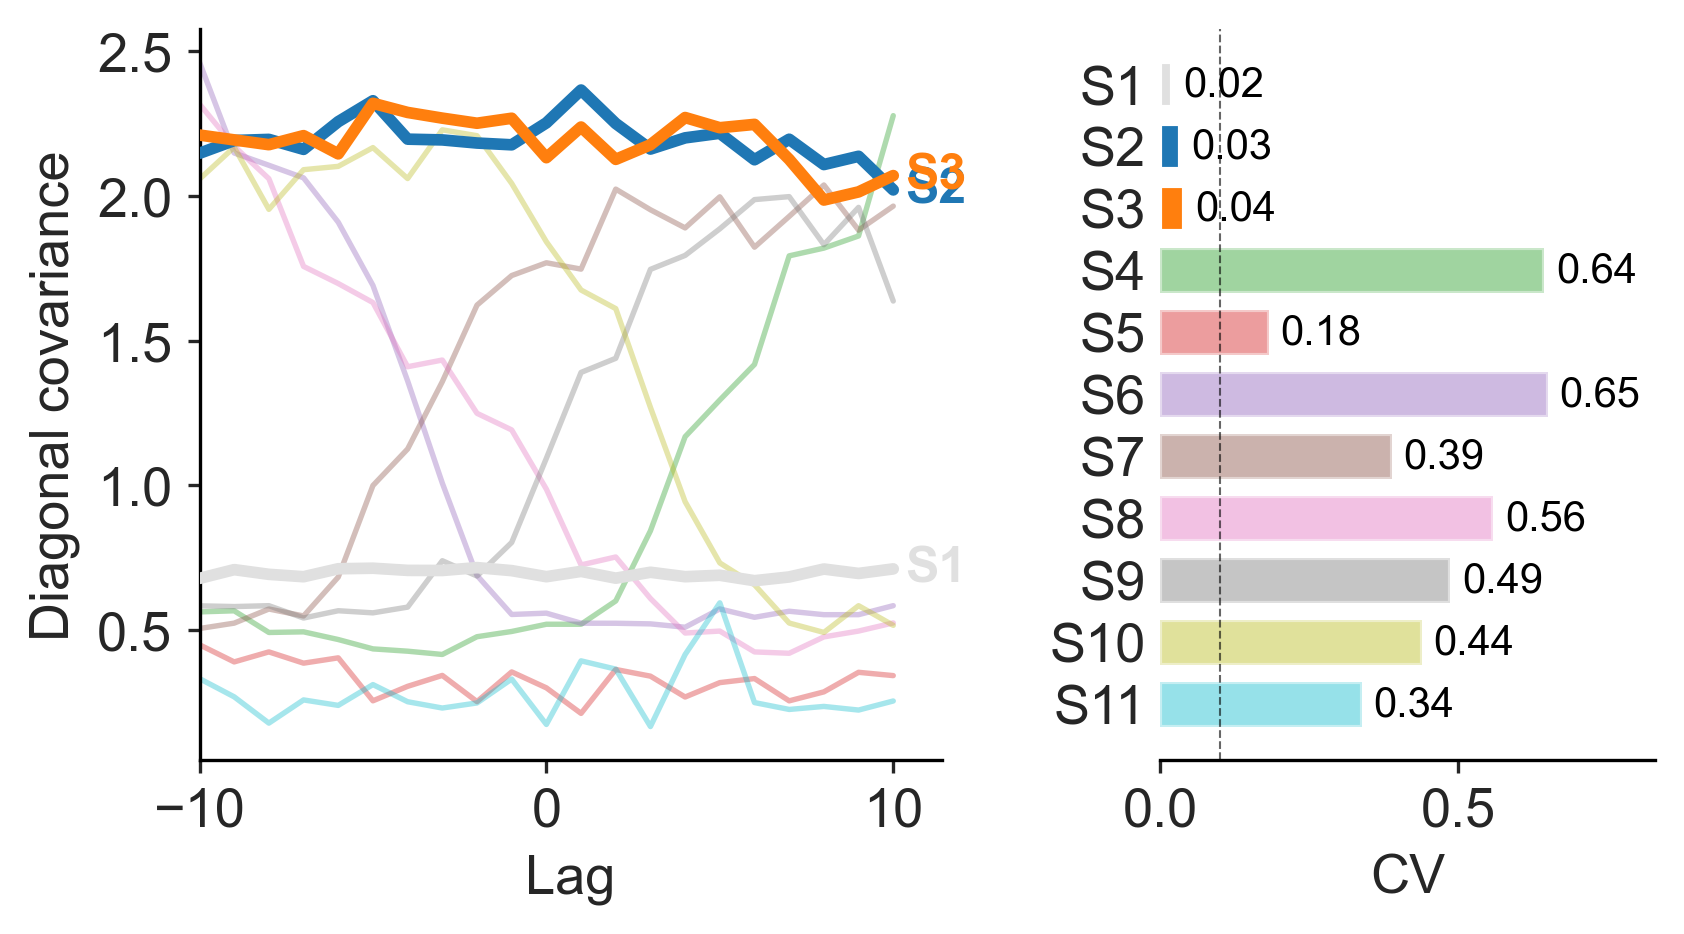

In [226]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Settings
# -----------------------------
n_states = len(untrunc_covs_raw)
dim_vec = np.arange(-num_emb // 2 + 1, num_emb // 2 + 1).astype(int)
cv_threshold = 0.1

# -----------------------------
# Extract diagonals and compute CV
# -----------------------------
diags = [np.diag(cov) for cov in untrunc_covs_raw]

cv_vals = []
for d in diags:
    mu = np.mean(d)
    sd = np.std(d)
    cv = sd / (mu + 1e-12)
    cv_vals.append(cv)

cv_vals = np.array(cv_vals)

# define stable states from the threshold
stable_states = np.where(cv_vals < cv_threshold)[0].tolist()

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(FIG_WIDTH-2, 3), constrained_layout=True)
gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.1)

ax = fig.add_subplot(gs[0, 0])
ax_cv = fig.add_subplot(gs[0, 1])

# -----------------------------
# Main covariance diagonal plot
# -----------------------------
for i, d in enumerate(diags):
    is_stable = i in stable_states
    ax.plot(
        dim_vec,
        d,
        color=colors[i],
        lw=2.8 if is_stable else 1.3,
        alpha=1.0 if is_stable else 0.38,
        zorder=4 if is_stable else 2,
    )

# optional: label only stable states at the right end
x_text = dim_vec[-1] + 0.35
for i in stable_states:
    ax.text(
        x_text,
        diags[i][-1],
        f"S{i + 1}",
        color=colors[i],
        fontsize=12,
        fontweight="bold",
        va="center",
        ha="left",
    )

ax.set_xlim(dim_vec[0], dim_vec[-1] + 1.4)
ax.set_xlabel("Lag", fontsize=13)
ax.set_ylabel("Diagonal covariance", fontsize=13)

ax.tick_params(axis="both", labelsize=13, width=0.8, length=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.set_axisbelow(True)

# -----------------------------
# CV panel
# -----------------------------
state_ids = np.arange(n_states)

for i in state_ids:
    ax_cv.barh(
        i,
        cv_vals[i],
        color=colors[i],
        alpha=1.0 if i in stable_states else 0.45,
        height=0.72,
    )

    # numeric label right next to each bar
    ax_cv.text(
        cv_vals[i] + 0.02,
        i,
        f"{cv_vals[i]:.2f}",
        va="center",
        ha="left",
        fontsize=10,
        color="black",
    )

ax_cv.set_yticks(state_ids)
ax_cv.set_yticklabels([f"S{i + 1}" for i in state_ids], fontsize=13)
ax_cv.invert_yaxis()

ax_cv.set_xlabel("CV", fontsize=13)
ax_cv.tick_params(axis="x", labelsize=13, width=0.8, length=3)
ax_cv.tick_params(axis="y", length=0)

ax_cv.spines["top"].set_visible(False)
ax_cv.spines["right"].set_visible(False)
ax_cv.spines["left"].set_visible(False)
ax_cv.spines["bottom"].set_linewidth(0.8)


ax_cv.set_axisbelow(True)

# threshold line at CV = 0.1
ax_cv.axvline(cv_threshold, color="k", lw=0.5, alpha=0.6, ls="--")



# leave room for the numeric labels
xmax = np.nanmax(cv_vals)
ax_cv.set_xlim(0, xmax + 0.18)

plt.show()

In [227]:
def relabel_freqs(burst_f):
    f0, f1 = burst_f
    label = f"{str(f0)}&{str(f1)}"
    return label


/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_18086/1009538708.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


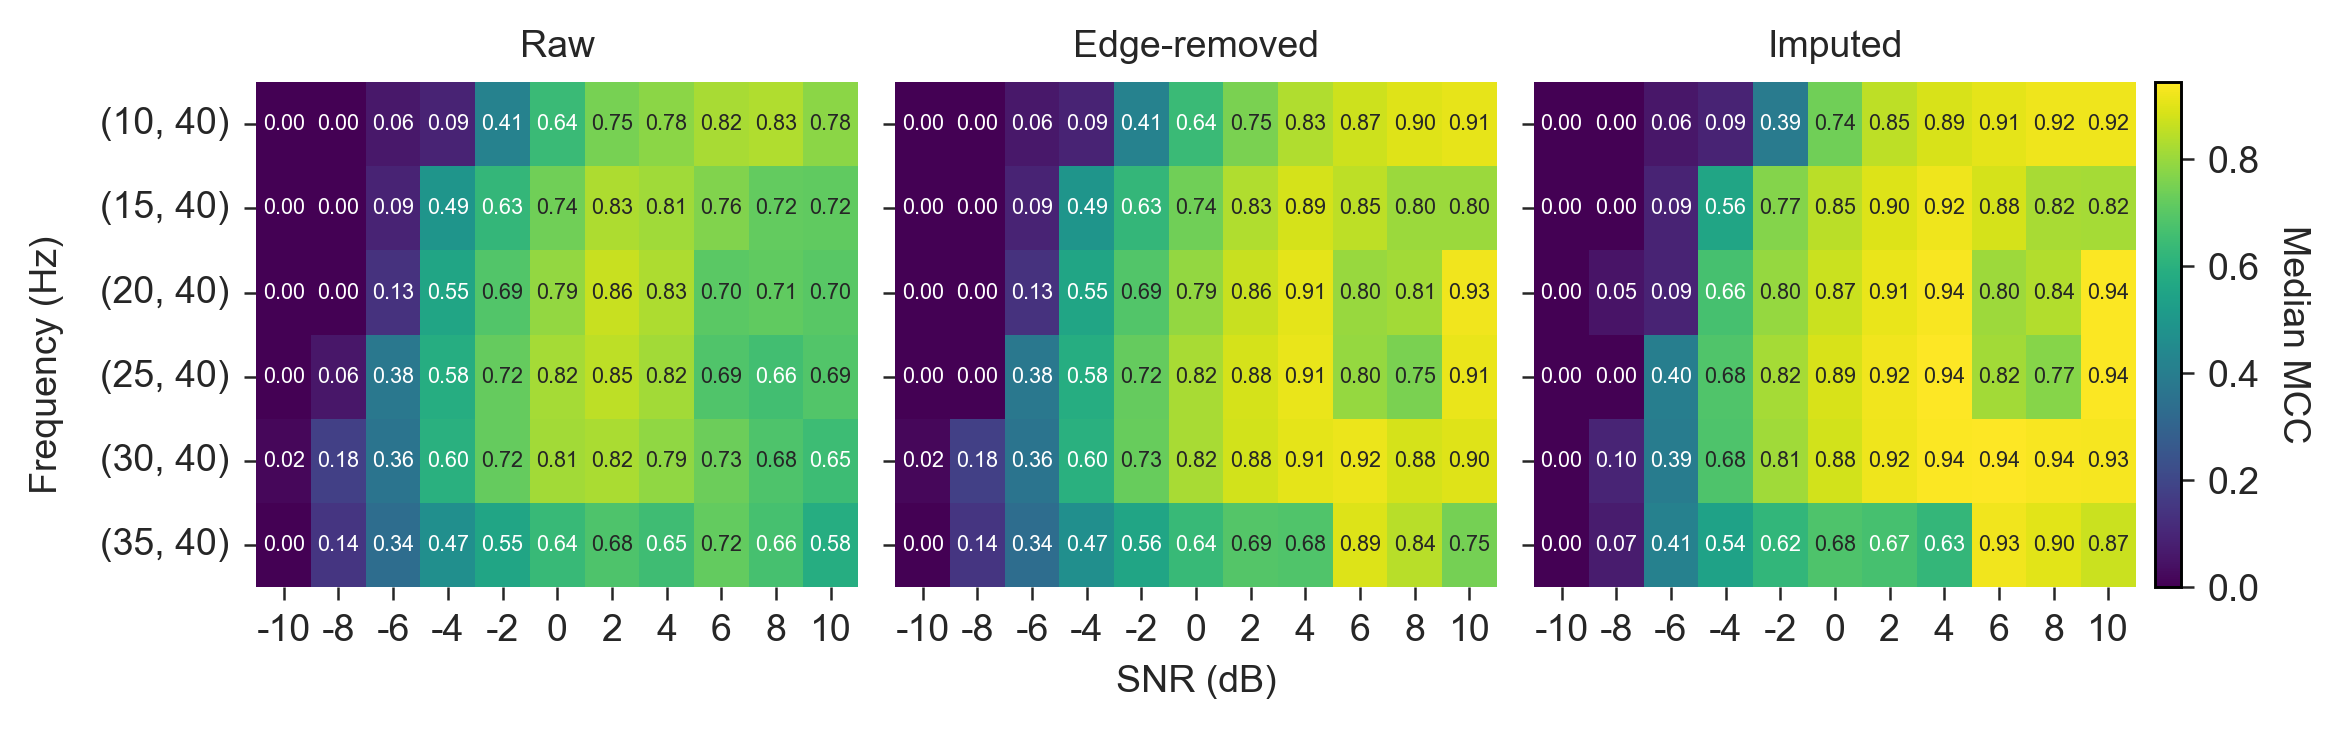

In [233]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MaxNLocator



#df_list = [pd.DataFrame(r) for r in res]
#df = pd.concat(df_list, axis = 0, ignore_index = True)

#df["burst_f"] = df["burst_f"].apply(tuple)
#df["burst_f"] = df["burst_f"].apply(relabel_freqs)



raw_heat = (df.query("method == 'DP-GMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0)
        .sort_index(axis=1))


edge_removed_heat = (df.query("method == 'DP-GMM (Edge-removed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending


imputed_heat = (df.query("method == 'DP-GMM (Imputed & Edge-removed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc="median")
        .sort_index(axis=0)
        .sort_index(axis=1))




mats = [
    raw_heat, edge_removed_heat, imputed_heat
]

vmin = np.nanmin([m.to_numpy() for m in mats])
vmax = np.nanmax([m.to_numpy() for m in mats])




common = dict(
    annot=True, fmt=".2f", annot_kws={"size": 5.2},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=False
)


fig, ax = plt.subplots(1, 3, figsize=(FIG_WIDTH, 2.5), sharex=True, sharey=True)

sns.heatmap(raw_heat, **common, ax=ax[0])
ax[0].set_title("Raw")

sns.heatmap(edge_removed_heat, **common, ax=ax[1])
ax[1].set_title("Edge-removed")

sns.heatmap(imputed_heat, **common, ax=ax[2])
ax[2].set_title("Imputed")





sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), fraction=0.02, pad=-0.05)
cbar.set_label("Median MCC",  rotation=270, labelpad=12)




for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")


fig.supylabel("Frequency (Hz)", fontsize = MY_FONT_SIZE)

ax[1].set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)


plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
fig.savefig(
    f"../figures/raw_figures/{sim_cond}_heatmaps.svg",
    bbox_inches="tight",
    pad_inches=0.03,
)

fig.savefig(
    f"../figures/raw_figures/{sim_cond}_heatmaps.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)

plt.show()


